In [12]:
"""
LEO to GEO Low Thrust Orbit Transfer using Basilisk

This script simulates a spacecraft performing a low-thrust spiral transfer
from Low Earth Orbit (LEO) to Geostationary Earth Orbit (GEO) using continuous
tangential thrust with Basilisk's astrodynamics framework.

Matches the dynamics of the reference scipy implementation.

Author: Based on Basilisk examples
"""

import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

from Basilisk import __path__
from Basilisk.architecture import messaging
from Basilisk.simulation import spacecraft
from Basilisk.simulation import extForceTorque
from Basilisk.simulation import simpleNav
from Basilisk.utilities import SimulationBaseClass
from Basilisk.utilities import macros
from Basilisk.utilities import unitTestSupport
from Basilisk.utilities import simIncludeGravBody

bskPath = __path__[0]

def run(I_sp, T, show_plots=True):
    """
    Main simulation function for LEO to GEO low thrust transfer
    
    Args:
        show_plots (bool): Whether to display plots at the end
    """
    
    # --- Constants (matching reference simulation) ---
    R_E = 6378.0  # km, Earth radius
    mu = 3.986e5  # km^3/s^2, Earth gravitational parameter
    
    # Initial orbit parameters
    a_init = 500.0  # km, altitude
    r_init = a_init + R_E  # km, orbital radius
    v_init = np.sqrt(mu / r_init)  # km/s, circular orbit velocity
    
    # Final orbit parameters
    a_final = 35000.0  # km, altitude (matching reference)
    r_final = a_final + R_E  # km
    
    # Spacecraft parameters
    m_0 = 500  # kg, initial mass
    
    # Engine parameters (matching reference)
    T = T / 1000000.0  # kN (1 N converted to kN)
    # I_sp = Isp  # s, specific impulse
    g_0 = 9.807e-3  # km/s^2, standard gravity
    
    print("=" * 60)
    print("LEO to GEO Low Thrust Transfer - Basilisk Implementation")
    print("=" * 60)
    print(f"Initial Altitude: {a_init} km")
    print(f"Final Target Altitude: {a_final} km")
    print(f"Max Thrust: {T*1000} N")
    print(f"Specific Impulse: {I_sp} s")
    print(f"Initial Mass: {m_0} kg")
    print(f"Initial Speed: {v_init:.3f} km/s")
    print("=" * 60)
    
    # --- Simulation Parameters ---
    dynTaskName = "dynTask"
    dynProcessName = "dynProcess"
    
    # Create simulation
    scSim = SimulationBaseClass.SimBaseClass()
    
    # Create process and task
    dynProcess = scSim.CreateNewProcess(dynProcessName)
    simTimeStep = macros.sec2nano(30.0)  # 1 second time steps for accuracy
    dynProcess.addTask(scSim.CreateNewTask(dynTaskName, simTimeStep))
    
    # --- Spacecraft Setup ---
    scObject = spacecraft.Spacecraft()
    scObject.ModelTag = "LEO-GEO-Spacecraft"
    
    # Mass properties
    I = [900., 0., 0.,
         0., 800., 0.,
         0., 0., 600.]
    scObject.hub.mHub = m_0
    scObject.hub.r_BcB_B = [[0.0], [0.0], [0.0]]
    scObject.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I)
    
    # Initial conditions - circular LEO orbit in XY plane
    # Convert km to meters for Basilisk
    scObject.hub.r_CN_NInit = [[r_init * 1000.0], [0.0], [0.0]]  # m
    scObject.hub.v_CN_NInit = [[0.0], [v_init * 1000.0], [0.0]]  # m/s
    scObject.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
    scObject.hub.omega_BN_BInit = [[0.0], [0.0], [0.0]]  # rad/s
    
    scSim.AddModelToTask(dynTaskName, scObject)
    
    # --- Gravity Setup ---
    # Use gravity factory to set up Earth gravity with exact mu
    gravFactory = simIncludeGravBody.gravBodyFactory()
    earth = gravFactory.createEarth()
    earth.isCentralBody = True
    earth.mu = mu * 1e9  # Convert km^3/s^2 to m^3/s^2 for exact match
    gravFactory.addBodiesTo(scObject)
    
    # --- External Force for Tangential Thrust ---
    extFTObject = extForceTorque.ExtForceTorque()
    extFTObject.ModelTag = "tangentialThrust"
    scObject.addDynamicEffector(extFTObject)
    scSim.AddModelToTask(dynTaskName, extFTObject)
    
    # --- Navigation ---
    sNavObject = simpleNav.SimpleNav()
    sNavObject.ModelTag = "SimpleNavigation"
    scSim.AddModelToTask(dynTaskName, sNavObject)
    sNavObject.scStateInMsg.subscribeTo(scObject.scStateOutMsg)
    
    # --- Data Logging ---
    samplingTime = macros.sec2nano(3600.0)  # Log every 60 seconds
    scStateLog = scObject.scStateOutMsg.recorder(samplingTime)
    scSim.AddModelToTask(dynTaskName, scStateLog)
    
    # --- Initialize Simulation ---
    scSim.InitializeSimulation()
    
    # --- THRUST PHASE ---
    print("\nStarting Thrust Phase...")
    
    # Define safe time limit (stay well below overflow at ~104 days)
    SAFE_TIME_LIMIT = macros.day2nano(90.0)  # 90 days per segment
    max_simulation_time = macros.day2nano(500.0)  # 500 days total max
    update_interval = macros.sec2nano(300.0)  # Update thrust every 10 seconds
    
    thrust_phase_complete = False
    orbit_count = 0
    last_y = 0.0
    
    # Storage for detailed trajectory
    thrust_positions = []
    thrust_velocities = []
    thrust_times = []
    thrust_masses = []
    
    # Track total elapsed time across all segments
    total_elapsed_time = 0.0  # in seconds
    segment_count = 0
    
    # Initial state
    current_scObject = scObject
    current_scSim = scSim
    current_extFTObject = extFTObject
    
    while total_elapsed_time < (max_simulation_time * macros.NANO2SEC) and not thrust_phase_complete:
        segment_count += 1
        print(f"\n--- Thrust Segment {segment_count} ---")
        
        # Run this segment up to safe time limit
        segment_start_time = 0
        segment_max_time = SAFE_TIME_LIMIT
        current_time = 0
        
        while current_time < segment_max_time and not thrust_phase_complete:
            # Execute simulation step
            current_scSim.ConfigureStopTime(current_time + update_interval)
            current_scSim.ExecuteSimulation()
            
            # Get current state (in meters and m/s)
            r_BN_N = current_scObject.dynManager.getStateObject("hubPosition").getState()
            v_BN_N = current_scObject.dynManager.getStateObject("hubVelocity").getState()
            current_mass = current_scObject.hub.mHub
            
            # Convert to km and km/s for calculations
            r_vec = np.array([r_BN_N[0][0], r_BN_N[1][0], r_BN_N[2][0]]) / 1000.0
            v_vec = np.array([v_BN_N[0][0], v_BN_N[1][0], v_BN_N[2][0]]) / 1000.0
            
            r_mag = np.linalg.norm(r_vec)
            v_mag = np.linalg.norm(v_vec)
            
            # Store trajectory data (with absolute time)
            thrust_positions.append(r_vec.copy())
            thrust_velocities.append(v_vec.copy())
            thrust_times.append(total_elapsed_time + current_time * macros.NANO2SEC)
            thrust_masses.append(current_mass)
            
            # Check for orbit crossing (Y coordinate sign change)
            current_y = r_vec[1]
            if last_y < 0 and current_y >= 0 and len(thrust_times) > 1:
                orbit_count += 1
            last_y = current_y
            
            # Check if reached destination
            if r_mag >= r_final:
                thrust_phase_complete = True
                print(f"Thrust Phase Complete!")
                print(f"Reached target radius at: {(total_elapsed_time + current_time * macros.NANO2SEC) / 86400.0:.4f} days")
                break
            
            # Calculate tangential thrust force (in velocity direction)
            if v_mag > 0:
                # Thrust direction is velocity direction (tangential)
                thrust_dir = v_vec / v_mag
                # Thrust magnitude in Newtons
                thrust_force_kN = T * thrust_dir  # kN
                # Convert to Newtons for Basilisk
                thrust_force_N = thrust_force_kN * 1000.0  # N
                
                # Apply thrust in inertial frame
                current_extFTObject.extForce_N = [
                    [thrust_force_N[0]],
                    [thrust_force_N[1]],
                    [thrust_force_N[2]]
                ]
            else:
                current_extFTObject.extForce_N = [[0.0], [0.0], [0.0]]
            
            # Update mass (fuel consumption): dm/dt = -T / (I_sp * g_0)
            dt = update_interval * macros.NANO2SEC  # seconds
            dm = -T / (I_sp * g_0) * dt  # kg (T in kN, result in kg)
            current_scObject.hub.mHub = max(10.0, current_mass + dm)  # Minimum 10 kg
            
            current_time += update_interval
        
        # Update total elapsed time
        total_elapsed_time += current_time * macros.NANO2SEC
        
        # If not complete, create new simulation for next segment
        if not thrust_phase_complete and total_elapsed_time < (max_simulation_time * macros.NANO2SEC):
            print(f"Segment time limit reached. Creating new simulation segment...")
            print(f"Progress: {(r_mag - r_init) / (r_final - r_init) * 100:.1f}% to target")
            
            # Save current state
            r_BN_N_seg = current_scObject.dynManager.getStateObject("hubPosition").getState()
            v_BN_N_seg = current_scObject.dynManager.getStateObject("hubVelocity").getState()
            current_mass_seg = current_scObject.hub.mHub
            
            # Create new simulation
            current_scSim = SimulationBaseClass.SimBaseClass()
            dynProcess_new = current_scSim.CreateNewProcess(dynProcessName + f"_{segment_count}")
            dynProcess_new.addTask(current_scSim.CreateNewTask(dynTaskName + f"_{segment_count}", simTimeStep))
            
            # Create new spacecraft
            current_scObject = spacecraft.Spacecraft()
            current_scObject.ModelTag = f"LEO-GEO-Spacecraft-Seg{segment_count}"
            current_scObject.hub.mHub = current_mass_seg
            current_scObject.hub.r_BcB_B = [[0.0], [0.0], [0.0]]
            current_scObject.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I)
            current_scObject.hub.r_CN_NInit = r_BN_N_seg
            current_scObject.hub.v_CN_NInit = v_BN_N_seg
            current_scObject.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
            current_scObject.hub.omega_BN_BInit = [[0.0], [0.0], [0.0]]
            
            current_scSim.AddModelToTask(dynTaskName + f"_{segment_count}", current_scObject)
            
            # Add gravity
            gravFactory_new = simIncludeGravBody.gravBodyFactory()
            earth_new = gravFactory_new.createEarth()
            earth_new.isCentralBody = True
            earth_new.mu = mu * 1e9
            gravFactory_new.addBodiesTo(current_scObject)
            
            # Add external force
            current_extFTObject = extForceTorque.ExtForceTorque()
            current_extFTObject.ModelTag = f"tangentialThrust_{segment_count}"
            current_scObject.addDynamicEffector(current_extFTObject)
            current_scSim.AddModelToTask(dynTaskName + f"_{segment_count}", current_extFTObject)
            
            # Initialize new simulation
            current_scSim.InitializeSimulation()
    
    thrust_end_time_sec = total_elapsed_time
    final_thrust_mass = current_scObject.hub.mHub
    propellant_used = m_0 - final_thrust_mass
    
    print(f"\nTime of flight: {thrust_end_time_sec / 86400.0:.4f} days")
    print(f"Number of orbits: {orbit_count}")
    print(f"Propellant used: {propellant_used:.4f} kg")
    print(f"Final speed (thrust cutoff): {v_mag:.3f} km/s")
    
    # --- COAST PHASE ---
    print("\nStarting Coast Phase...")
    
    # Get final state from thrust phase
    r_BN_N_final = current_scObject.dynManager.getStateObject("hubPosition").getState()
    v_BN_N_final = current_scObject.dynManager.getStateObject("hubVelocity").getState()
    
    # Create a NEW simulation for coast phase
    scSim2 = SimulationBaseClass.SimBaseClass()
    dynProcess2 = scSim2.CreateNewProcess(dynProcessName + "_coast")
    dynProcess2.addTask(scSim2.CreateNewTask(dynTaskName + "_coast", simTimeStep))
    
    # Create new spacecraft with final state from thrust phase
    scObject2 = spacecraft.Spacecraft()
    scObject2.ModelTag = "LEO-GEO-Spacecraft-Coast"
    scObject2.hub.mHub = final_thrust_mass
    scObject2.hub.r_BcB_B = [[0.0], [0.0], [0.0]]
    scObject2.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I)
    
    # Set initial conditions from end of thrust phase
    scObject2.hub.r_CN_NInit = r_BN_N_final
    scObject2.hub.v_CN_NInit = v_BN_N_final
    scObject2.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
    scObject2.hub.omega_BN_BInit = [[0.0], [0.0], [0.0]]
    
    scSim2.AddModelToTask(dynTaskName + "_coast", scObject2)
    
    # Add gravity to new spacecraft
    gravFactory2 = simIncludeGravBody.gravBodyFactory()
    earth2 = gravFactory2.createEarth()
    earth2.isCentralBody = True
    earth2.mu = mu * 1e9
    gravFactory2.addBodiesTo(scObject2)
    
    # Add navigation
    sNavObject2 = simpleNav.SimpleNav()
    sNavObject2.ModelTag = "SimpleNavigation2"
    scSim2.AddModelToTask(dynTaskName + "_coast", sNavObject2)
    sNavObject2.scStateInMsg.subscribeTo(scObject2.scStateOutMsg)
    
    # Data logging for coast phase
    coast_sample_interval = macros.sec2nano(3600.0)  # Sample every 10 minutes
    scStateLog2 = scObject2.scStateOutMsg.recorder(coast_sample_interval)
    scSim2.AddModelToTask(dynTaskName + "_coast", scStateLog2)
    
    # Initialize coast simulation
    scSim2.InitializeSimulation()
    
    # Coast for 14 days
    t_coast = macros.day2nano(14.0)
    scSim2.ConfigureStopTime(t_coast)
    scSim2.ExecuteSimulation()
    
    # Extract coast phase data
    coast_times_nano = scStateLog2.times()
    coast_r_BN_N = scStateLog2.r_BN_N / 1000.0  # Convert to km
    coast_v_BN_N = scStateLog2.v_BN_N / 1000.0  # Convert to km/s
    
    coast_positions = []
    coast_velocities = []
    coast_times = []
    
    for i in range(len(coast_times_nano)):
        coast_positions.append(coast_r_BN_N[i])
        coast_velocities.append(coast_v_BN_N[i])
        # Add thrust end time to get absolute time
        coast_times.append(thrust_end_time_sec + coast_times_nano[i] * macros.NANO2SEC)
    
    coast_positions = np.array(coast_positions)
    coast_velocities = np.array(coast_velocities)
    
    # Analyze coast phase orbit
    coast_radii = [np.linalg.norm(r) for r in coast_positions]
    r_coast_apo = max(coast_radii)
    r_coast_per = min(coast_radii)
    r_coast_avg = (r_coast_apo + r_coast_per) / 2.0
    r_coast_error = (r_coast_avg - r_final) / r_final * 100.0
    e_coast = (r_coast_apo - r_coast_per) / (r_coast_apo + r_coast_per)
    
    final_v_vec = coast_velocities[-1]
    v_final_coast = np.linalg.norm(final_v_vec)
    
    # --- Final Summary (single consolidated output) ---
    print("\n" + "=" * 60)
    print("SIMULATION COMPLETE - FINAL RESULTS")
    print("=" * 60)
    print(f"Initial Altitude: {a_init} km")
    print(f"Final Target Altitude: {a_final} km")
    print(f"Max Thrust: {T*1000} N")
    print(f"Initial speed: {v_init:.3f} km/s")
    print(f"Final (thrust cutoff) speed: {v_mag:.3f} km/s")
    print(f"Propellant used: {propellant_used:.4f} kg")
    print(f"Time of flight: {thrust_end_time_sec / 86400.0:.4f} days")
    print(f"Number of orbits: {orbit_count}")
    print(f"Coast Radius Percent Error: {r_coast_error:.3f} %")
    print(f"Coast eccentricity: {e_coast:.5f}")
    print(f"Speed after coast: {v_final_coast:.3f} km/s")
    print("=" * 60)
    
    # --- Plotting ---
    if show_plots:
        # Convert to arrays
        thrust_positions = np.array(thrust_positions)
        coast_positions = np.array(coast_positions)
        thrust_velocities = np.array(thrust_velocities)
        coast_velocities = np.array(coast_velocities)
        
        # Create summary text
        summary_text = (
            f"Initial Altitude: {a_init} km\n"
            f"Final Target Altitude: {a_final} km\n"
            f"Max Thrust: {T*1000:.3f} N\n"
            f"Initial speed: {v_init:.3f} km/s\n"
            f"Final (thrust cutoff) speed: {v_mag:.3f} km/s\n"
            f"Propellant used: {propellant_used:.4f} kg\n"
            f"Time of flight: {thrust_end_time_sec / 86400.0:.4f} days\n"
            f"Number of orbits: {orbit_count}\n"
            f"Coast Radius Error: {r_coast_error:.3f} %\n"
            f"Coast eccentricity: {e_coast:.5f}\n"
            f"Speed after coast: {v_final_coast:.3f} km/s"
        )
        
        # Plot 1: Orbit trajectory
        plt.rc("font", size=18)
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.set_aspect("equal")
        ax.axis("off")
        
        # Earth
        earth_circle = Circle((0, 0), R_E, ec="none", fc="C0")
        ax.add_patch(earth_circle)
        ax.annotate("Earth", xy=(0, 0), ha="center", va="center", color="white")
        
        # Target orbit
        target_circle = Circle((0, 0), r_final, ec="C1", fc="none", lw=2, ls="--")
        ax.add_patch(target_circle)
        
        # Trajectories
        ax.plot(thrust_positions[:, 0], thrust_positions[:, 1], 
                color="C2", lw=1, label="Thrust Phase")
        ax.plot(coast_positions[:, 0], coast_positions[:, 1], 
                color="C3", lw=1, label="Coast Phase")
        
        ax.legend(loc="upper right", fontsize=10)
        
        # Add summary text box
        ax.text(0.02, 0.98, summary_text, transform=ax.transAxes,
                fontsize=10, verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8))
        
        plt.tight_layout()
        
        # Plot 2: Altitude vs Time
        thrust_altitudes = [np.linalg.norm(r) - R_E for r in thrust_positions]
        coast_altitudes = [np.linalg.norm(r) - R_E for r in coast_positions]
        thrust_time_days = np.array(thrust_times) / 86400.0
        coast_time_days = np.array(coast_times) / 86400.0
        
        plt.figure(figsize=(10, 6))
        plt.plot(thrust_time_days, thrust_altitudes, 'g-', linewidth=2, label='Thrust Phase')
        plt.plot(coast_time_days, coast_altitudes, 'r-', linewidth=2, label='Coast Phase')
        plt.axhline(y=a_final, color='b', linestyle='--', linewidth=1, label='Target Altitude')
        plt.xlabel('Time (days)', fontsize=12)
        plt.ylabel('Altitude (km)', fontsize=12)
        plt.title('Altitude vs Time', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        
        # Plot 3: Velocity Magnitude vs Time
        thrust_vel_mag = [np.linalg.norm(v) for v in thrust_velocities]
        coast_vel_mag = [np.linalg.norm(v) for v in coast_velocities]
        
        plt.figure(figsize=(10, 6))
        plt.plot(thrust_time_days, thrust_vel_mag, 'g-', linewidth=2, label='Thrust Phase')
        plt.plot(coast_time_days, coast_vel_mag, 'r-', linewidth=2, label='Coast Phase')
        plt.xlabel('Time (days)', fontsize=12)
        plt.ylabel('Velocity (km/s)', fontsize=12)
        plt.title('Velocity Magnitude vs Time', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        
        plt.show()
    
    return scSim, thrust_end_time_sec / 86400.0


# if __name__ == "__main__":
#     run(show_plots=True)


LEO to GEO Low Thrust Transfer - Basilisk Implementation
Initial Altitude: 500.0 km
Final Target Altitude: 35000.0 km
Max Thrust: 0.01 N
Specific Impulse: 1000 s
Initial Mass: 500 kg
Initial Speed: 7.613 km/s

Starting Thrust Phase...

--- Thrust Segment 1 ---
Segment time limit reached. Creating new simulation segment...
Progress: 0.8% to target

--- Thrust Segment 2 ---
Segment time limit reached. Creating new simulation segment...
Progress: 1.7% to target

--- Thrust Segment 3 ---
Segment time limit reached. Creating new simulation segment...
Progress: 2.7% to target

--- Thrust Segment 4 ---
Segment time limit reached. Creating new simulation segment...
Progress: 3.8% to target

--- Thrust Segment 5 ---
Segment time limit reached. Creating new simulation segment...
Progress: 5.0% to target

--- Thrust Segment 6 ---

Time of flight: 540.0000 days
Number of orbits: 6805
Propellant used: 47.5742 kg
Final speed (thrust cutoff): 6.645 km/s

Starting Coast Phase...

SIMULATION COMPLETE -

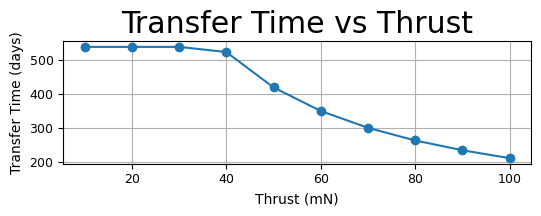

In [13]:
import matplotlib.pyplot as plt

T_list = [10,20,30,40,50,60,70,80,90,100]
times = []

for T in T_list:
    scSim, t_days = run(I_sp=1000, T=T, show_plots=False)

    times.append(t_days)
    print(f"T = {T} mN → Time = {t_days:.2f} days")



[540.0000000000001, 540.0000000000001, 540.0000000000001, 524.7916666666667, 419.8333333333333, 349.86111111111114, 299.8819444444445, 262.3958333333333, 233.23958333333334, 209.91666666666666]


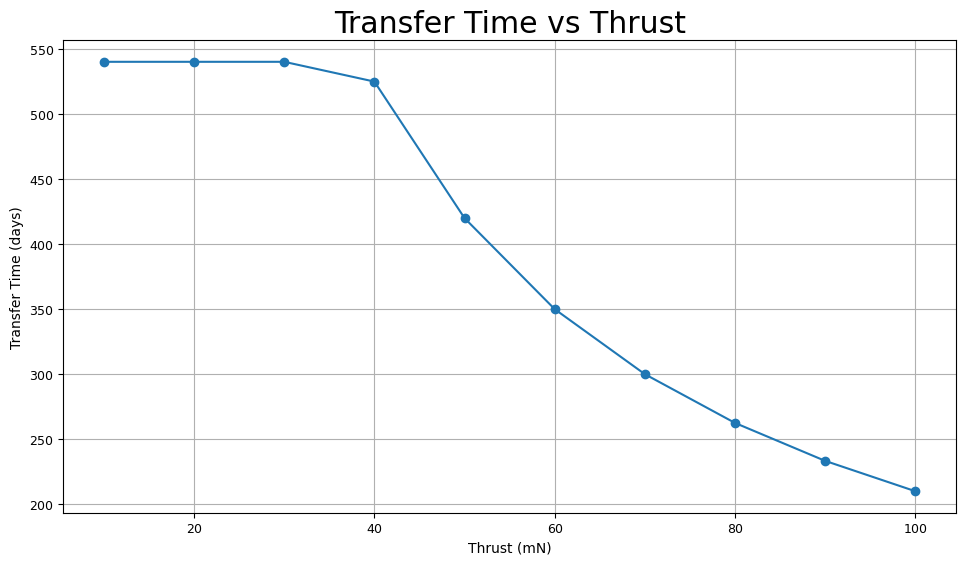

In [17]:
print(times)
plt.figure(figsize=(10, 6))
plt.plot(T_list, times, marker='o')
plt.xlabel("Thrust (mN)")
plt.ylabel("Transfer Time (days)")
plt.title("Transfer Time vs Thrust")
plt.grid()
plt.show()

LEO to GEO Low Thrust Transfer - Basilisk Implementation
Initial Altitude: 500.0 km
Final Target Altitude: 35000.0 km
Max Thrust: 0.001 N
Specific Impulse: 1000 s
Initial Mass: 500 kg
Initial Speed: 7.613 km/s

Starting Thrust Phase...

--- Thrust Segment 1 ---
Segment time limit reached. Creating new simulation segment...
Progress: 0.1% to target

--- Thrust Segment 2 ---
Segment time limit reached. Creating new simulation segment...
Progress: 0.2% to target

--- Thrust Segment 3 ---
Segment time limit reached. Creating new simulation segment...
Progress: 0.2% to target

--- Thrust Segment 4 ---
Segment time limit reached. Creating new simulation segment...
Progress: 0.3% to target

--- Thrust Segment 5 ---
Segment time limit reached. Creating new simulation segment...
Progress: 0.4% to target

--- Thrust Segment 6 ---

Time of flight: 540.0000 days
Number of orbits: 8071
Propellant used: 4.7574 kg
Final speed (thrust cutoff): 7.521 km/s

Starting Coast Phase...

SIMULATION COMPLETE -

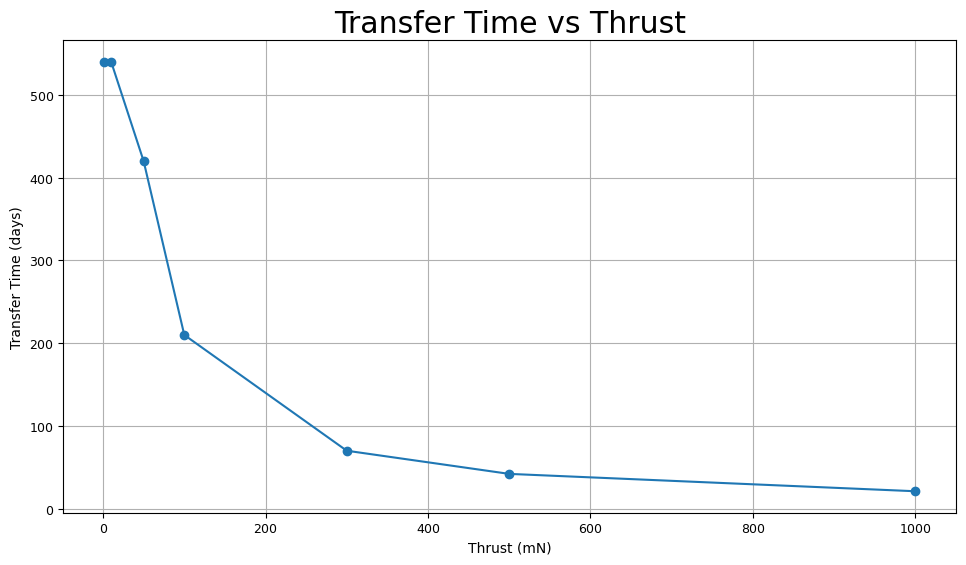

In [18]:

T_list = [1,10,50,100,300,500,1000]
times = []

for T in T_list:
    scSim, t_days = run(I_sp=1000, T=T, show_plots=False)

    times.append(t_days)
    print(f"T = {T} mN → Time = {t_days:.2f} days")
print(times)
plt.figure(figsize=(10, 6))
plt.plot(T_list, times, marker='o')
plt.xlabel("Thrust (mN)")
plt.ylabel("Transfer Time (days)")
plt.title("Transfer Time vs Thrust")
plt.grid()
plt.show()

LEO to GEO Low Thrust Transfer - Basilisk Implementation
Initial Altitude: 500.0 km
Final Target Altitude: 35000.0 km
Max Thrust: 0.3 N
Specific Impulse: 1000 s
Initial Mass: 500 kg
Initial Speed: 7.613 km/s

Starting Thrust Phase...

--- Thrust Segment 1 ---
Thrust Phase Complete!
Reached target radius at: 69.9757 days

Time of flight: 69.9757 days
Number of orbits: 476
Propellant used: 184.9465 kg
Final speed (thrust cutoff): 3.104 km/s

Starting Coast Phase...

SIMULATION COMPLETE - FINAL RESULTS
Initial Altitude: 500.0 km
Final Target Altitude: 35000.0 km
Max Thrust: 0.3 N
Initial speed: 7.613 km/s
Final (thrust cutoff) speed: 3.104 km/s
Propellant used: 184.9465 kg
Time of flight: 69.9757 days
Number of orbits: 476
Coast Radius Percent Error: 0.031 %
Coast eccentricity: 0.00817
Speed after coast: 3.092 km/s
isp = 1000 mN → Time = 69.98 days
LEO to GEO Low Thrust Transfer - Basilisk Implementation
Initial Altitude: 500.0 km
Final Target Altitude: 35000.0 km
Max Thrust: 0.3 N
Specif

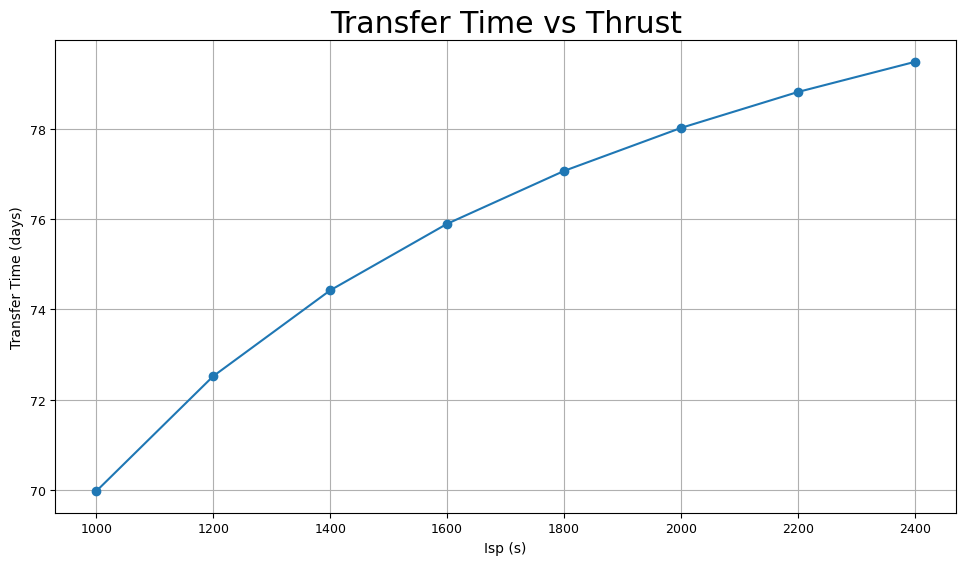

In [19]:
isp_list = [1000,1200,1400,1600,1800,2000,2200,2400]
times = []

for isp in isp_list:
    scSim, t_days = run(I_sp=isp, T=300, show_plots=False)

    times.append(t_days)
    print(f"isp = {isp} mN → Time = {t_days:.2f} days")
print(times)
plt.figure(figsize=(10, 6))
plt.plot(isp_list, times, marker='o')
plt.xlabel("Isp (s)")
plt.ylabel("Transfer Time (days)")
plt.title("Transfer Time vs Thrust")
plt.grid()
plt.show()


LEO to GEO Low Thrust Transfer - Basilisk Implementation
Initial Altitude: 500.0 km
Final Target Altitude: 35000.0 km
Max Thrust: 0.1 N
Specific Impulse: 1000 s
Initial Mass: 500 kg
Initial Speed: 7.613 km/s

Starting Thrust Phase...

--- Thrust Segment 1 ---
Segment time limit reached. Creating new simulation segment...
Progress: 12.9% to target

--- Thrust Segment 2 ---
Segment time limit reached. Creating new simulation segment...
Progress: 56.4% to target

--- Thrust Segment 3 ---
Thrust Phase Complete!
Reached target radius at: 209.9167 days

Time of flight: 209.9167 days
Number of orbits: 1428
Propellant used: 184.9373 kg
Final speed (thrust cutoff): 3.104 km/s

Starting Coast Phase...

SIMULATION COMPLETE - FINAL RESULTS
Initial Altitude: 500.0 km
Final Target Altitude: 35000.0 km
Max Thrust: 0.1 N
Initial speed: 7.613 km/s
Final (thrust cutoff) speed: 3.104 km/s
Propellant used: 184.9373 kg
Time of flight: 209.9167 days
Number of orbits: 1428
Coast Radius Percent Error: 0.001 %

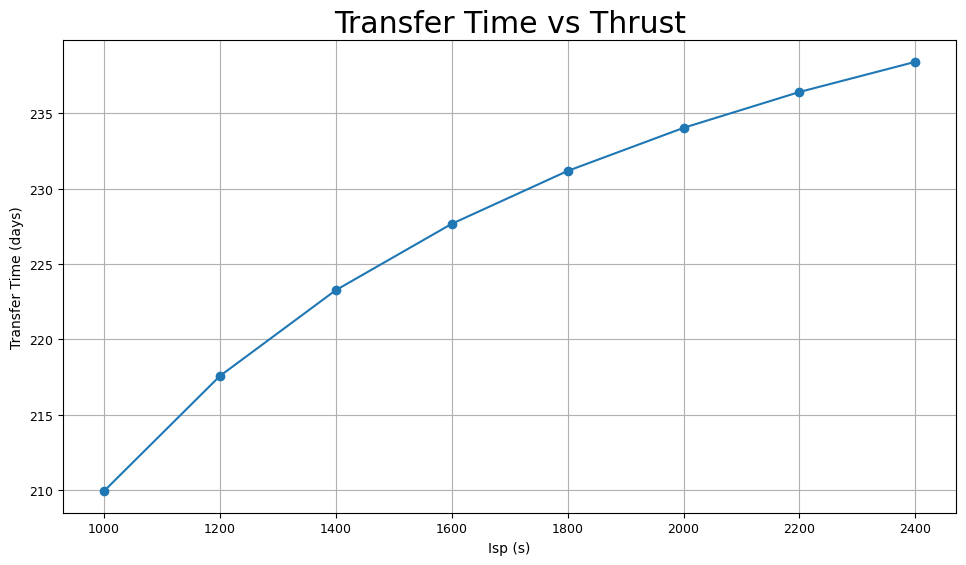

In [20]:
isp_list = [1000,1200,1400,1600,1800,2000,2200,2400]
times = []

for isp in isp_list:
    scSim, t_days = run(I_sp=isp, T=100, show_plots=False)

    times.append(t_days)
    print(f"isp = {isp} mN → Time = {t_days:.2f} days")
print(times)
plt.figure(figsize=(10, 6))
plt.plot(isp_list, times, marker='o')
plt.xlabel("Isp (s)")
plt.ylabel("Transfer Time (days)")
plt.title("Transfer Time vs Thrust")
plt.grid()
plt.show()
